### Processing EMTP-RV outputs

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from simulation import Simulation

In [3]:
from utils import create_white_list
from utils import plot_machine_signals, plot_machine_delta_signals
from utils import plot_bus_voltages_rms, plot_bus_voltage_dir
from utils import tsi_from_angle, tsi_from_omega

In [4]:
# EMTP file name (without extension):
name = 'IEEE39_Wind_v5_22_5_2026'

# Create a list of variable names:
varnames = [
    '/Teta_1_SM1',   # rotor angle
    '/Omega_1_SM1',  # rotor speed
    '/PowerAng_SM1', # power angle
    '/Pe_SM1',       # electrical power
    '/vd_SM1',  # d-axis stator voltage
    '/id_SM1',  # d-axis stator current
    '/Ef_SM1',  # EMF voltage (q-axis)
    '/vq_SM1',  # q-axis stator voltage
    '/iq_SM1',  # q-axis stator current
]
# List of machines that are excluded.
exclude = [8, 10]
# List of bus voltages.
buses = np.arange(start=1, stop=30).tolist()
buses.append(39)

In [5]:
white_list = create_white_list(varnames, exclude, buses)
white_list

['BUS1/Vrms_a',
 'BUS1/Vrms_b',
 'BUS1/Vrms_c',
 'BUS1/V1_mag',
 'BUS1/V1_phase',
 'BUS2/Vrms_a',
 'BUS2/Vrms_b',
 'BUS2/Vrms_c',
 'BUS2/V1_mag',
 'BUS2/V1_phase',
 'BUS3/Vrms_a',
 'BUS3/Vrms_b',
 'BUS3/Vrms_c',
 'BUS3/V1_mag',
 'BUS3/V1_phase',
 'BUS4/Vrms_a',
 'BUS4/Vrms_b',
 'BUS4/Vrms_c',
 'BUS4/V1_mag',
 'BUS4/V1_phase',
 'BUS5/Vrms_a',
 'BUS5/Vrms_b',
 'BUS5/Vrms_c',
 'BUS5/V1_mag',
 'BUS5/V1_phase',
 'BUS6/Vrms_a',
 'BUS6/Vrms_b',
 'BUS6/Vrms_c',
 'BUS6/V1_mag',
 'BUS6/V1_phase',
 'BUS7/Vrms_a',
 'BUS7/Vrms_b',
 'BUS7/Vrms_c',
 'BUS7/V1_mag',
 'BUS7/V1_phase',
 'BUS8/Vrms_a',
 'BUS8/Vrms_b',
 'BUS8/Vrms_c',
 'BUS8/V1_mag',
 'BUS8/V1_phase',
 'BUS9/Vrms_a',
 'BUS9/Vrms_b',
 'BUS9/Vrms_c',
 'BUS9/V1_mag',
 'BUS9/V1_phase',
 'BUS10/Vrms_a',
 'BUS10/Vrms_b',
 'BUS10/Vrms_c',
 'BUS10/V1_mag',
 'BUS10/V1_phase',
 'BUS11/Vrms_a',
 'BUS11/Vrms_b',
 'BUS11/Vrms_c',
 'BUS11/V1_mag',
 'BUS11/V1_phase',
 'BUS12/Vrms_a',
 'BUS12/Vrms_b',
 'BUS12/Vrms_c',
 'BUS12/V1_mag',
 'BUS12/V1_phase',
 

In [6]:
# Assemble .m and .mda files.
m_file = name + 'm.m'
mda_file = name + '.mda'

In [7]:
# Read the simulation .mda file.
sim = Simulation(mda_file, m_file, white_list)
sim.load_data()

In [8]:
# Export signals to DataFrame.
data = sim.to_dataframe()
data

,time,BUS1/Vrms_a,BUS1/Vrms_b,BUS1/Vrms_c,BUS1/V1_mag,BUS1/V1_phase,BUS2/Vrms_a,BUS2/Vrms_b,BUS2/Vrms_c,BUS2/V1_mag,...,FFC_WP2/Wind_Turbine/PMSG_T_rotor,FFC_WP2/Wind_Turbine/PMSG_w_rotor,DEV3/P,DEV3/Q,DEV3/V0,DEV3/V1,DEV3/V2,DEV3/I0,DEV3/I1,DEV3/I2
0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.902532,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.004,0.506939,0.311984,0.612487,0.241572,-0.681384,0.472182,0.325906,0.611992,0.237268,...,-0.919051,0.988992,8.758458e+07,5.760670e+07,0.299861,68507.330650,45353.794074,0.000590,204.555838,135.197273
2,0.008,0.682998,0.702825,0.706523,0.483259,-0.669880,0.670720,0.692494,0.692155,0.474719,...,-0.919076,0.988989,1.772013e+08,5.799284e+07,0.094836,137067.441313,5713.914110,0.000323,413.696670,16.893776
3,0.012,0.873509,0.760929,0.920502,0.724876,-0.669866,0.843736,0.753779,0.912463,0.712066,...,-0.919101,0.988987,2.670990e+08,5.807038e+07,0.041568,205597.469900,44631.392718,0.000570,623.584626,133.554810
4,0.016,0.966657,0.991471,1.000919,0.966524,-0.666857,0.948887,0.976999,0.980845,0.949437,...,-0.919125,0.988986,3.568779e+08,5.829258e+07,0.063004,274134.318435,11321.525791,0.000127,833.174981,33.598797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,3.984,1.013933,1.013779,1.014443,1.014047,-30.704511,1.003326,1.002722,1.003698,1.003242,...,-0.914219,1.001872,3.701661e+08,1.988133e+06,3.023719,289669.718124,162.148884,0.086758,851.933096,0.710535
997,3.988,1.014787,1.013907,1.013734,1.014139,-30.781203,1.004244,1.002703,1.002985,1.003306,...,-0.914214,1.001882,3.701898e+08,1.999750e+06,3.043470,289688.166871,271.754657,0.087034,851.934835,0.270412
998,3.992,1.014169,1.013835,1.014665,1.014219,-30.858810,1.003480,1.002703,1.003866,1.003345,...,-0.914207,1.001892,3.702006e+08,1.968539e+06,3.034485,289699.301634,195.494592,0.086213,851.926970,0.602213
999,3.996,1.014866,1.014190,1.013864,1.014303,-30.935643,1.004248,1.002918,1.003010,1.003387,...,-0.914199,1.001903,3.701984e+08,1.936595e+06,3.039934,289711.535758,246.085430,0.086816,851.885363,0.353378


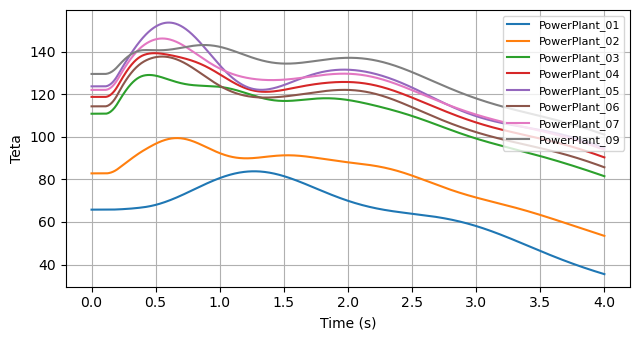

In [9]:
# Plot machine "Theta" values.
plot_machine_signals(data, 'Teta')

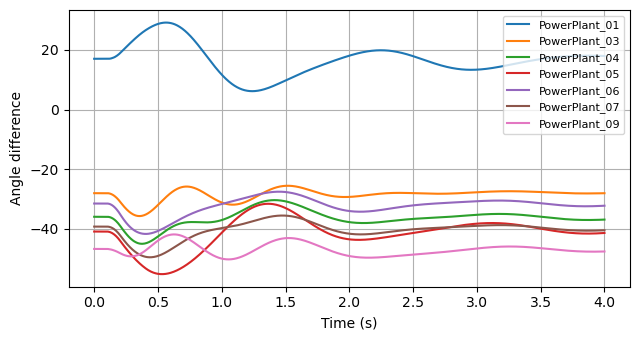

In [10]:
# Machine swing angles with regards to the slack bus.
plot_machine_delta_signals(data)

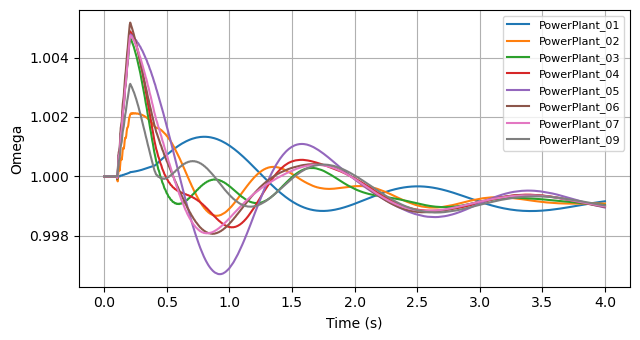

In [11]:
# Plot machine "Omega" values.
plot_machine_signals(data, 'Omega')

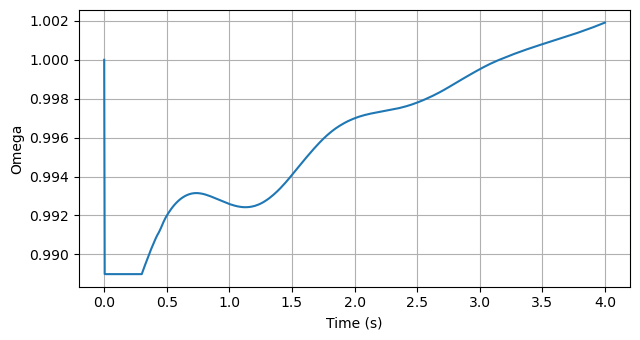

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(data['time'], data[ 'FFC_WP2/Wind_Turbine/PMSG_w_rotor'])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Omega')
ax.grid()
fig.tight_layout()
plt.show()

In [13]:
# Transient stability index.
sim_tsi = tsi_from_angle(data)
print(f'TSI = {sim_tsi}')
sim_tsi = tsi_from_omega(data, tol=2e-3)
print(f'TSI = {sim_tsi}')

TSI = 0
TSI = 0


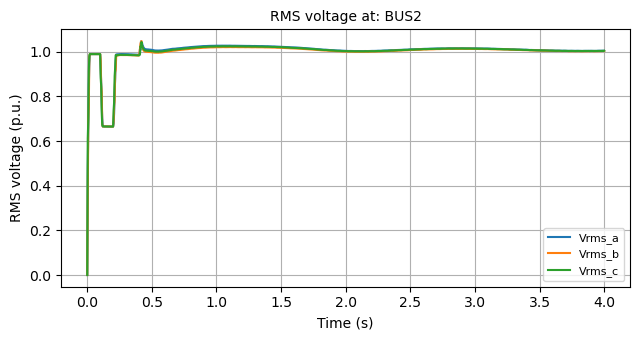

In [14]:
plot_bus_voltages_rms(data, 'BUS2')

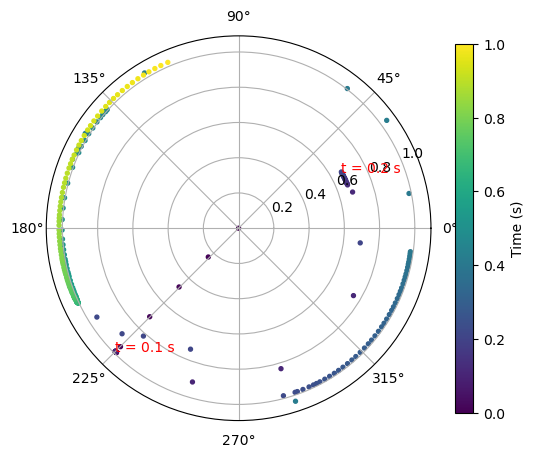

In [15]:
# The first second of the direct sequence BUS2 voltage 
# on a time-annotated polar plot.
plot_bus_voltage_dir(data, 'BUS2', limit=1)

### Reading external pickle file with simulation signals

In [16]:
with open(file='SC3T100ms.pkl', mode='rb') as fp:
    data_all = pickle.load(fp)

In [17]:
data_all.keys()

dict_keys(['SC3BUS0', 'SC3BUS1', 'SC3BUS2', 'SC3BUS3', 'SC3BUS4', 'SC3BUS5', 'SC3BUS6', 'SC3BUS7', 'SC3BUS8', 'SC3BUS9'])

In [18]:
# Extract DataFrame for a select simulation case.
data_bus1 = data_all['SC3BUS3']
data_bus1

,time,BUS2/Vrms_a,BUS2/Vrms_b,BUS2/Vrms_c,BUS2/V1_mag,BUS2/V1_phase,BUS3/Vrms_a,BUS3/Vrms_b,BUS3/Vrms_c,BUS3/V1_mag,...,PowerPlant_07/Teta_1_SM1,PowerPlant_09/Teta_1_SM1,PowerPlant_01/Omega_1_SM1,PowerPlant_02/Omega_1_SM1,PowerPlant_03/Omega_1_SM1,PowerPlant_04/Omega_1_SM1,PowerPlant_05/Omega_1_SM1,PowerPlant_06/Omega_1_SM1,PowerPlant_07/Omega_1_SM1,PowerPlant_09/Omega_1_SM1
0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,113.234267,118.875851,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.002,0.461115,0.163269,0.339911,0.119134,-7.330885,0.457900,0.178888,0.316720,0.116959,...,113.234268,118.875851,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.004,0.534631,0.288574,0.584098,0.238374,-7.342731,0.538956,0.278873,0.562118,0.233961,...,113.234271,118.875856,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.006,0.551467,0.534613,0.689837,0.357626,-7.336794,0.551884,0.515185,0.675706,0.350982,...,113.234277,118.875863,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.008,0.674824,0.690314,0.699459,0.476850,-7.331428,0.662969,0.675939,0.687315,0.467987,...,113.234285,118.875873,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,3.992,0.989772,0.989946,0.989778,0.989832,17.423830,0.971403,0.971587,0.971431,0.971473,...,138.988490,144.349119,0.999813,0.999762,0.999794,0.999728,0.999673,0.999724,0.999738,0.999765
1997,3.994,0.989944,0.989864,0.989732,0.989846,17.413771,0.971574,0.971516,0.971363,0.971484,...,138.977152,144.338957,0.999814,0.999760,0.999792,0.999726,0.999670,0.999723,0.999737,0.999764
1998,3.996,0.989947,0.989742,0.989898,0.989862,17.403191,0.971593,0.971382,0.971513,0.971496,...,138.965773,144.328743,0.999815,0.999758,0.999790,0.999725,0.999668,0.999722,0.999736,0.999763
1999,3.998,0.989803,0.989837,0.989994,0.989878,17.393066,0.971443,0.971456,0.971623,0.971507,...,138.954350,144.318473,0.999816,0.999756,0.999789,0.999723,0.999666,0.999721,0.999735,0.999762


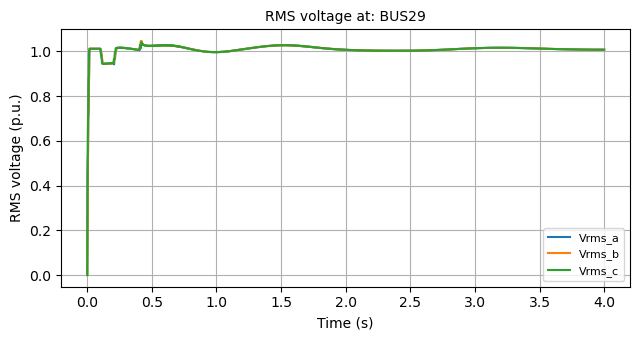

In [19]:
plot_bus_voltages_rms(data_bus1, 'BUS29')